<a href="https://colab.research.google.com/github/GiacomoSilvello/UAV-damage-assessment/blob/main/RescueNet_TRAINING_INCREMENTALE_res713.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RescueNet · TRAINING INCREMENTALE — res713 (A100)

Da usare **tutte le volte dopo il primo training**: **Runtime → Esegui tutto**.

1. monta Drive
2. prepara repo e dataset
3. imposta i parametri
4. **riprende dal checkpoint più avanzato** e aggiunge N epoche
5. rigenera maschere e metriche
6. esporta i CSV aggiornati
7. mostra due esempi
8. confronto originale / ground truth / predizione

## 1 · Monta Google Drive
Da lanciare a ogni nuova sessione.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2 · Setup ambiente (repo + dataset + patch)

Comune a **tutti** i regimi: il codice e le immagini non dipendono dalla risoluzione.
Da rilanciare a ogni nuova sessione, perché `/content` viene azzerato.

Le patch sono *idempotenti*: rilanciare la cella non duplica righe in `train.py`.

In [ ]:
import os, subprocess

REPO_DIR = '/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation'
WORK_DIR = f'{REPO_DIR}/Segmentation-Experiments'
ZIP_PATH = '/content/drive/MyDrive/RescueNet.zip'

# --- Repo + dipendenze ---
if not os.path.isdir(REPO_DIR):
    !git clone -q https://github.com/BinaLab/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation.git
!pip install -q tensorboardX

# --- Dataset: ---
if not os.path.isdir('/content/dataset/train/train-label-img') or \
   len(os.listdir('/content/dataset/train/train-label-img')) == 0:
    print("Estrazione dataset...")
    !rm -rf /content/dataset && mkdir -p /content/dataset
    !unzip -o -q "{ZIP_PATH}" -d /content/dataset/
else:
    print("Dataset già estratto.")

%cd {WORK_DIR}

# --- Patch al codice (idempotenti) ---
with open('train.py') as f:
    train_src = f.read()
if 'train_epochs, loss_epochs' not in train_src.split('\n')[0]:
    !sed -i '1i train_epochs, loss_epochs, mIoU_epochs, mAcc_epochs, allAcc_epochs = [], [], [], [], []' train.py
    print("Patch liste train.py applicata.")

!sed -i 's/torch.load(model_path)/torch.load(model_path, weights_only=False)/g' models/resnet.py
!sed -i 's/from data import RescueNetv2 as dataset/from data import RescueNet as dataset/g' train.py test.py
!sed -i 's|if epoch_log / args.save_freq > 2:|if False:  # PATCH: conserva tutti i checkpoint|g' train.py

# --- Percorsi dataset assoluti nel config ---
CONFIG = 'config/rescuenet-pspnet101.yaml'
!sed -i 's|^  data_root: .*|  data_root: /content/dataset|' {CONFIG}
!sed -i 's|^  dataset_dir: .*|  dataset_dir: /content/dataset|' {CONFIG}
!sed -i 's/use_pretrained_weights: True/use_pretrained_weights: False/g' {CONFIG}

# --- Verifica allineamento immagini/label ---
for split, atteso in [('train', 823), ('val', 449), ('test', 450)]:
    o = f'/content/dataset/{split}/{split}-org-img'
    l = f'/content/dataset/{split}/{split}-label-img'
    no = len(os.listdir(o)) if os.path.isdir(o) else 0
    nl = len(os.listdir(l)) if os.path.isdir(l) else 0
    stato = "OK" if no == nl and no > 0 else "DISALLINEATO"
    print(f"  [{split}] immagini={no}  label={nl}  -> {stato}")

print("\nSetup completato.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.9 MB/s eta 0:00:00
Estrazione dataset...
mapname:  conversion of  failed
/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments
Patch liste train.py applicata.
  [train] immagini=3595  label=3595  -> OK
  [val] immagini=449  label=449  -> OK
  [test] immagini=450  label=450  -> OK

Setup completato.


## 3 · Parametri del regime (713 × 713, A100)

Cella che definisce percorsi e iperparametri e li scrive nel config.
Va rilanciata a ogni sessione *prima* di training o test, perché il config viene
riscaricato insieme alla repo.

`BASE_LR` è scalato linearmente sul batch (regola: batch ×N ⇒ lr ×N, partendo da
batch 2 / lr 0.001 del config originale). Cambiando `BATCH_SIZE`, il learning rate
si aggiorna da solo.

`TRAIN_SIZE` deve essere della forma **8k+1** (713, 769, 825, 1025…) per via di
`zoom_factor: 8`: un valore diverso fa crashare PSPNet.

In [ ]:
import os

# ============================================================
# PARAMETRI DEL REGIME
REGIME      = 'res713'      # etichetta usata in tutti i percorsi di output
TRAIN_SIZE  = 713           # deve essere 8k+1
BATCH_SIZE  = 8
# ============================================================

BASE_LR = round(0.001 * BATCH_SIZE / 2, 6)   # scaling lineare sul batch

WORK_DIR   = '/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments'
CONFIG     = 'config/rescuenet-pspnet101.yaml'
DRIVE_BASE = '/content/drive/MyDrive/RescueNet_Output'
MODEL_DIR  = f'{DRIVE_BASE}/pspnet101_{REGIME}/model'
ORIG_DIR   = f'{DRIVE_BASE}/test_originali'          # condiviso fra regimi
GT_DIR     = f'{DRIVE_BASE}/colormasks'              # ground truth colorate (condivise)
os.makedirs(MODEL_DIR, exist_ok=True)

def pred_dir(ep):  return f'{DRIVE_BASE}/predictions2_{REGIME}_ep{ep}'
def csv_ris(ep):   return f'{DRIVE_BASE}/risultati2_{REGIME}_ep{ep}.csv'
def csv_met(ep):   return f'{DRIVE_BASE}/metriche2_{REGIME}_ep{ep}.csv'

if os.path.isdir(WORK_DIR):
    %cd {WORK_DIR}
    !sed -i 's/^  train_h: .*/  train_h: {TRAIN_SIZE}/'   {CONFIG}
    !sed -i 's/^  train_w: .*/  train_w: {TRAIN_SIZE}/'   {CONFIG}
    !sed -i 's/^  test_h: .*/  test_h: {TRAIN_SIZE}/'     {CONFIG}
    !sed -i 's/^  test_w: .*/  test_w: {TRAIN_SIZE}/'     {CONFIG}
    !sed -i 's/^  batch_size: .*/  batch_size: {BATCH_SIZE}/' {CONFIG}
    !sed -i 's/^  base_lr: .*/  base_lr: {BASE_LR}/'      {CONFIG}
    !sed -i 's/^  sync_bn: .*/  sync_bn: False/'          {CONFIG}
    !sed -i 's/^  save_freq: .*/  save_freq: 1/'          {CONFIG}
    !sed -i 's|^  save_path: .*|  save_path: {MODEL_DIR}|' {CONFIG}

print(f"Regime: {REGIME} | risoluzione {TRAIN_SIZE}x{TRAIN_SIZE} | batch {BATCH_SIZE} | lr {BASE_LR}")
print(f"Checkpoint -> {MODEL_DIR}")
if (TRAIN_SIZE - 1) % 8 != 0:
    print(f"ATTENZIONE: {TRAIN_SIZE} non è 8k+1, il training crasherà.")

Regime: res713 | risoluzione 713x713 | batch 8 | lr 0.004
Checkpoint -> /content/drive/MyDrive/RescueNet_Output/pspnet101_res713/model


## 4 · Training INCREMENTALE (+N epoche)

Riprende dal checkpoint più avanzato del regime corrente, ricaricando anche lo
stato dell'optimizer.

In [ ]:
%cd {WORK_DIR}
import glob, re, torch

EPOCHE_DA_AGGIUNGERE = 10

ckpts = glob.glob(f"{MODEL_DIR}/*.pth")
if not ckpts:
    print(f"Nessun checkpoint in {REGIME}. Lancia prima la cella 4 (training da zero).")
else:
    def ep_di(f):
        m = re.search(r'(\d+)\.pth$', f)
        return int(m.group(1)) if m else -1
    ckpt = max(ckpts, key=ep_di)
    epoca_attuale = torch.load(ckpt, map_location='cpu').get('epoch', ep_di(ckpt))
    target = epoca_attuale + EPOCHE_DA_AGGIUNGERE

    print(f"Riprendo da {os.path.basename(ckpt)} (epoca {epoca_attuale})")
    print(f"Alleno fino all'epoca {target}  |  checkpoint già salvati: {len(ckpts)}")

    !sed -i 's|^  resume:.*|  resume: {ckpt}|'  {CONFIG}
    !sed -i 's|^  epochs: .*|  epochs: {target}|' {CONFIG}

    print("\nParametri effettivi:")
    !grep -E "^  (train_h|batch_size|base_lr|epochs|resume):" {CONFIG}
    print("\nAvvio training...\n")
    !sed -i '1i params_list, train_accuracy, train_epochs, train_loss, val_accuracy, val_epochs, val_loss = [], [], [], [], [], [], []' train.py
    !python train.py --config {CONFIG}
    print(f"\nCompletato. Checkpoint totali: {len(glob.glob(f'{MODEL_DIR}/*.pth'))}")

/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments
Riprendo da train_epoch_90.pth (epoca 90)
Alleno fino all'epoca 100  |  checkpoint già salvati: 90

Parametri effettivi:
  base_lr: 0.004
  batch_size: 8
  epochs: 100
  resume: /content/drive/MyDrive/RescueNet_Output/pspnet101_res713/model/train_epoch_90.pth
  train_h: 713

Avvio training...

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/lay

## 5 · Test — maschere + metriche

Due passate su `test.py`: `mode: vis` genera le maschere colorate, `mode: test`
calcola mIoU/mAcc/allAcc. Tutto viene salvato **su Drive**, etichettato con regime
ed epoche, quindi resta disponibile anche dopo il reset del runtime.

Copia anche, una volta sola, le immagini originali del test set su Drive.

In [ ]:
%cd {WORK_DIR}
import yaml, glob, re, shutil, subprocess

# --- Epoche del modello che sto per testare ---
ckpts = glob.glob(f"{MODEL_DIR}/*.pth")
if not ckpts:
    raise SystemExit(f"Nessun checkpoint in {REGIME}: allena prima il modello.")
def ep_di(f):
    m = re.search(r'(\d+)\.pth$', f)
    return int(m.group(1)) if m else -1
best_ckpt = max(ckpts, key=ep_di)
EPOCA = ep_di(best_ckpt)

SAVE_FOLDER = pred_dir(EPOCA)
os.makedirs(SAVE_FOLDER, exist_ok=True)
print(f"Modello: {os.path.basename(best_ckpt)} ({EPOCA} epoche)")
print(f"Maschere -> predictions_{REGIME}_ep{EPOCA}\n")

# --- File colori e nomi classi ---
with open('/content/colors.txt', 'w') as f:
    f.write("0 0 0\n61 230 250\n180 120 120\n235 255 7\n255 184 6\n255 0 0\n"
            "255 0 245\n140 140 140\n160 150 20\n4 250 7\n255 235 0")
with open('/content/names.txt', 'w') as f:
    f.write("Background\nWater\nBuilding-No-Damage\nBuilding-Minor-Damage\n"
            "Building-Major-Damage\nBuilding-Total-Destruction\nVehicle\n"
            "Road-Clear\nRoad-Blocked\nTree\nPool")

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)
for _, sub in cfg.items():
    if isinstance(sub, dict) and 'test_h' in sub:
        sub['colors_path'] = '/content/colors.txt'
        sub['names_path']  = '/content/names.txt'
        sub['save_folder'] = SAVE_FOLDER
        sub['model_path']  = best_ckpt
        sub['print_freq']  = 1
        sub['evaluate']    = True
with open(CONFIG, 'w') as f:
    yaml.dump(cfg, f)

# --- FASE 1: maschere colorate ---
print("FASE 1 — generazione maschere...\n")
!sed -i 's/mode: test/mode: vis/g' {CONFIG}
!python test.py --config {CONFIG}

# --- FASE 2: metriche numeriche, catturate e salvate su Drive ---
print("\nFASE 2 — calcolo metriche...\n")
!sed -i 's/mode: vis/mode: test/g' {CONFIG}
out = subprocess.run(["python", "test.py", "--config", CONFIG],
                     capture_output=True, text=True).stdout
print(out)
with open(f'{DRIVE_BASE}/metriche_{REGIME}_ep{EPOCA}.txt', 'w') as f:
    f.write(out)

# --- Recupero maschere se test.py ha scritto in locale ---
if len([f for f in os.listdir(SAVE_FOLDER) if f.endswith('.png')]) == 0:
    for src in ['outputs', '/content/results']:
        if os.path.isdir(src) and any(f.endswith('.png') for f in os.listdir(src)):
            for f in os.listdir(src):
                if f.endswith('.png'):
                    shutil.copy(os.path.join(src, f), os.path.join(SAVE_FOLDER, f))
            print(f"Maschere recuperate da '{src}' e messe al sicuro su Drive.")
            break

# --- Copia una-tantum delle immagini originali (condivise fra regimi) ---
os.makedirs(ORIG_DIR, exist_ok=True)
org_locale = '/content/dataset/test/test-org-img'
if os.path.isdir(org_locale) and len(os.listdir(ORIG_DIR)) == 0:
    for f in os.listdir(org_locale):
        if f.lower().endswith(('.jpg', '.png')):
            shutil.copy(os.path.join(org_locale, f), os.path.join(ORIG_DIR, f))
    print(f"Copiate {len(os.listdir(ORIG_DIR))} immagini originali su Drive.")

n = len([f for f in os.listdir(SAVE_FOLDER) if f.endswith('.png')])
print(f"\nTest completato: {n} maschere in predictions_{REGIME}_ep{EPOCA}")

/content/RescueNet-A-High-Resolution-Post-Disaster-UAV-Dataset-for-Semantic-Segmentation/Segmentation-Experiments
Modello: train_epoch_100.pth (100 epoche)
Maschere -> predictions_res713_ep100

FASE 1 — generazione maschere...

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please i

## 6 · Export CSV — risultati per immagine + metriche globali

Produce due file su Drive: uno con una riga per immagine (percentuali per classe,
grado di danno 0–3, mIoU e accuracy per immagine) e uno con le metriche aggregate.


In [ ]:
import os, re, glob
import numpy as np, pandas as pd
from PIL import Image

GT_LOCALE = '/content/dataset/test/test-label-img'

cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
if not cart:
    raise SystemExit(f"Nessuna cartella predictions_{REGIME}_ep*.")
def n_ep(p):
    m = re.search(r'_ep(\d+)$', p); return int(m.group(1)) if m else -1
PRED_DIR = max(cart, key=n_ep); EPOCHE = n_ep(PRED_DIR)
print(f"Elaboro {REGIME} @ {EPOCHE} epoche")

CLASSI = [('Background',(0,0,0),0), ('Water',(61,230,250),1),
          ('Building-No-Damage',(180,120,120),2), ('Building-Minor-Damage',(235,255,7),3),
          ('Building-Major-Damage',(255,184,6),4), ('Building-Total-Destruction',(255,0,0),5),
          ('Vehicle',(255,0,245),6), ('Road-Clear',(140,140,140),7),
          ('Road-Blocked',(160,150,20),8), ('Tree',(4,250,7),9), ('Pool',(255,235,0),10)]
NC = len(CLASSI)
LIVELLO = {'Building-No-Damage':0, 'Building-Minor-Damage':1,
           'Building-Major-Damage':2, 'Building-Total-Destruction':3}

def rgb2idx(arr):
    out = np.full(arr.shape[:2], 255, dtype=np.uint8)
    for _, col, idx in CLASSI:
        out[np.all(arr == np.array(col), axis=-1)] = idx
    return out

maschere = sorted(f for f in os.listdir(PRED_DIR) if f.endswith('.png'))
print(f"Immagini: {len(maschere)}")
gt_ok = os.path.isdir(GT_LOCALE)
if not gt_ok:
    print("Ground truth non disponibile: niente colonne IoU né metriche globali.")

righe = []
inter = np.zeros(NC); union = np.zeros(NC); target = np.zeros(NC)

for i, m in enumerate(maschere, 1):
    base = m[:-4]
    arr = np.array(Image.open(os.path.join(PRED_DIR, m)).convert('RGB'))
    pred = rgb2idx(arr)

    # Calcolo delle percentuali (basato sulla predizione originale)
    tot_orig = pred.size
    riga = {'ID_Immagine': base, 'Regime': REGIME, 'Epoche': EPOCHE}
    perc = {}
    for nome, _, idx in CLASSI:
        p = float((pred == idx).sum()) / tot_orig * 100
        perc[nome] = p
        riga[f'perc_{nome}'] = round(p, 4)

    px_ed = sum(perc[n] for n in LIVELLO)
    danno = (sum(perc[n] * LIVELLO[n] for n in LIVELLO) / px_ed) if px_ed > 0 else np.nan
    riga['Danno_Edifici_0_3'] = round(danno, 4) if px_ed > 0 else ''
    riga['Perc_Edifici_Totale'] = round(px_ed, 4)

    if gt_ok:
        gtp = os.path.join(GT_LOCALE, base + '_lab.png')
        if os.path.exists(gtp):
            gt = np.array(Image.open(gtp))
            if gt.ndim == 3: gt = gt[:, :, 0]

            if gt.shape != pred.shape:
                # Uso NEAREST per non distorcere le classi (gli indici)
                pred_img = Image.fromarray(pred).resize((gt.shape[1], gt.shape[0]), Image.NEAREST)
                pred = np.array(pred_img)

            tot_eval = pred.size
            ious = []

            for nome, _, idx in CLASSI:
                pm, gm = (pred == idx), (gt == idx)
                it = np.logical_and(pm, gm).sum()
                un = np.logical_or(pm, gm).sum()


                inter[idx] += it
                union[idx] += un
                target[idx] += gm.sum()

                # --- FIX: Ignoro l'indice 0 (Sfondo) dal mIoU dell'immagine ---
                if idx != 0 and un > 0:
                    ious.append(it / un)

            riga['mIoU_immagine'] = round(float(np.mean(ious)), 4) if ious else ''
            riga['Accuracy_immagine'] = round(float((pred == gt).sum() / tot_eval), 4)
        else:
            riga['mIoU_immagine'] = ''; riga['Accuracy_immagine'] = ''

    righe.append(riga)
    if i % 100 == 0: print(f"  {i}/{len(maschere)}...")
df = pd.DataFrame(righe)
df.to_csv(csv_ris(EPOCHE), index=False)
print(f"\nSalvato: risultati_{REGIME}_ep{EPOCHE}.csv  ({len(df)} righe)")

if gt_ok and union.sum() > 0:
    iou = np.divide(inter, union, out=np.zeros(NC), where=union > 0)
    acc = np.divide(inter, target, out=np.zeros(NC), where=target > 0)

    # --- FIX: Escludo lo Sfondo (indice 0) dalle medie globali ---
    pres_no_bg = (union > 0)
    pres_no_bg[0] = False # Forzo a False la presenza della classe Sfondo

    miou_globale = round(float(iou[pres_no_bg].mean()), 4) if pres_no_bg.any() else 0.0
    macc_globale = round(float(acc[pres_no_bg].mean()), 4) if pres_no_bg.any() else 0.0

    met = [{'Metrica':'Regime', 'Valore':REGIME},
           {'Metrica':'Epoche', 'Valore':EPOCHE},
           {'Metrica':'N_immagini', 'Valore':len(df)},
           {'Metrica':'mIoU_Globale', 'Valore': miou_globale},
           {'Metrica':'mAcc_Globale', 'Valore': macc_globale},
           {'Metrica':'allAcc (Pixel Accuracy)', 'Valore':round(float(inter.sum()/target.sum()),4)}]

    for nome, _, idx in CLASSI:
        met.append({'Metrica': f'IoU_{nome}', 'Valore': round(float(iou[idx]), 4)})

    dfm = pd.DataFrame(met)
    dfm.to_csv(csv_met(EPOCHE), index=False)
    print(f"Salvato: metriche_{REGIME}_ep{EPOCHE}.csv\n")
    print(dfm.to_string(index=False))

## 7 · Due esempi casuali con grado di danno

Legge le maschere del modello più allenato del regime corrente. Funziona con il
solo Drive montato (celle 1 e 3), senza rifare training né test.

Il **seed** viene stampato: annotandolo e reinserendolo in `SEED` riottieni sempre
la stessa coppia — utile quando trovi due esempi buoni per la tesi.

Maschere: res713 @ 100 epoche

SEED usato: 999547   (per rivedere questi esempi: SEED = 999547)
Immagini: ['11774', '12260']



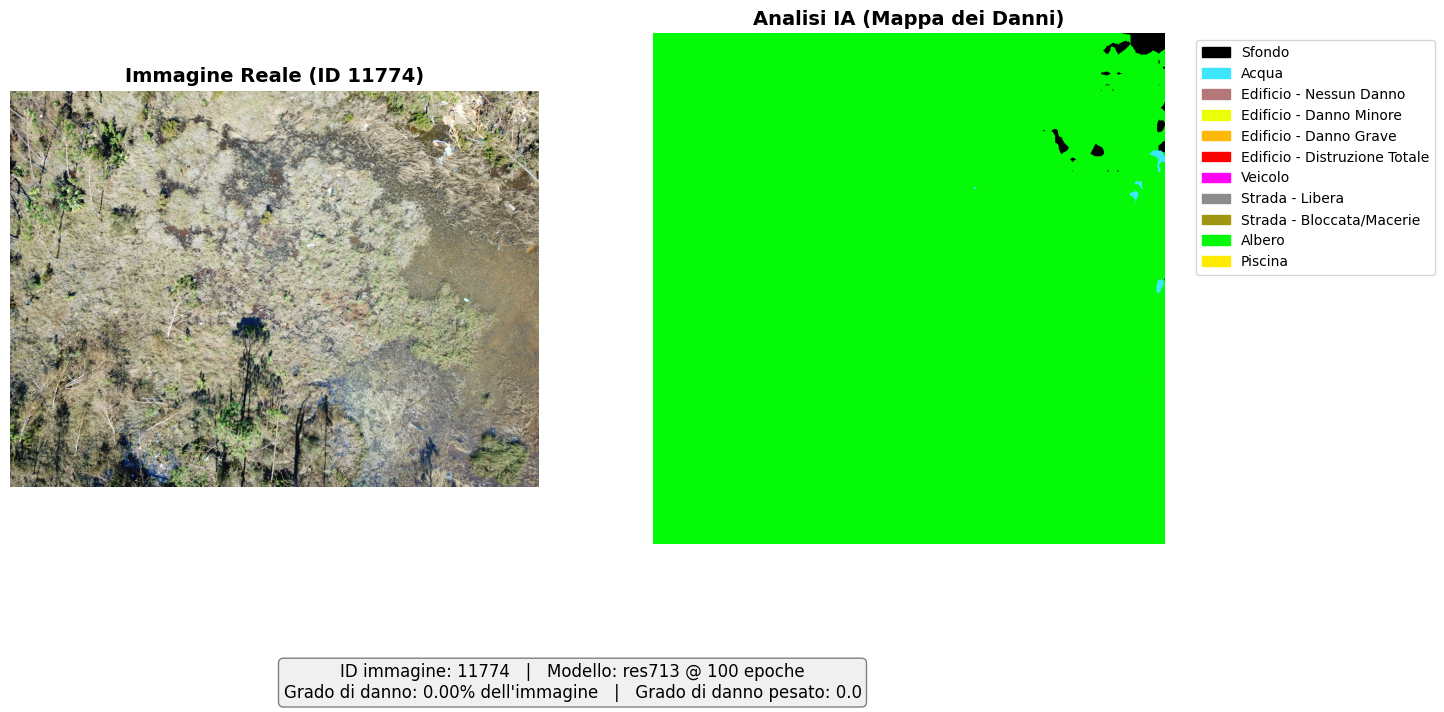

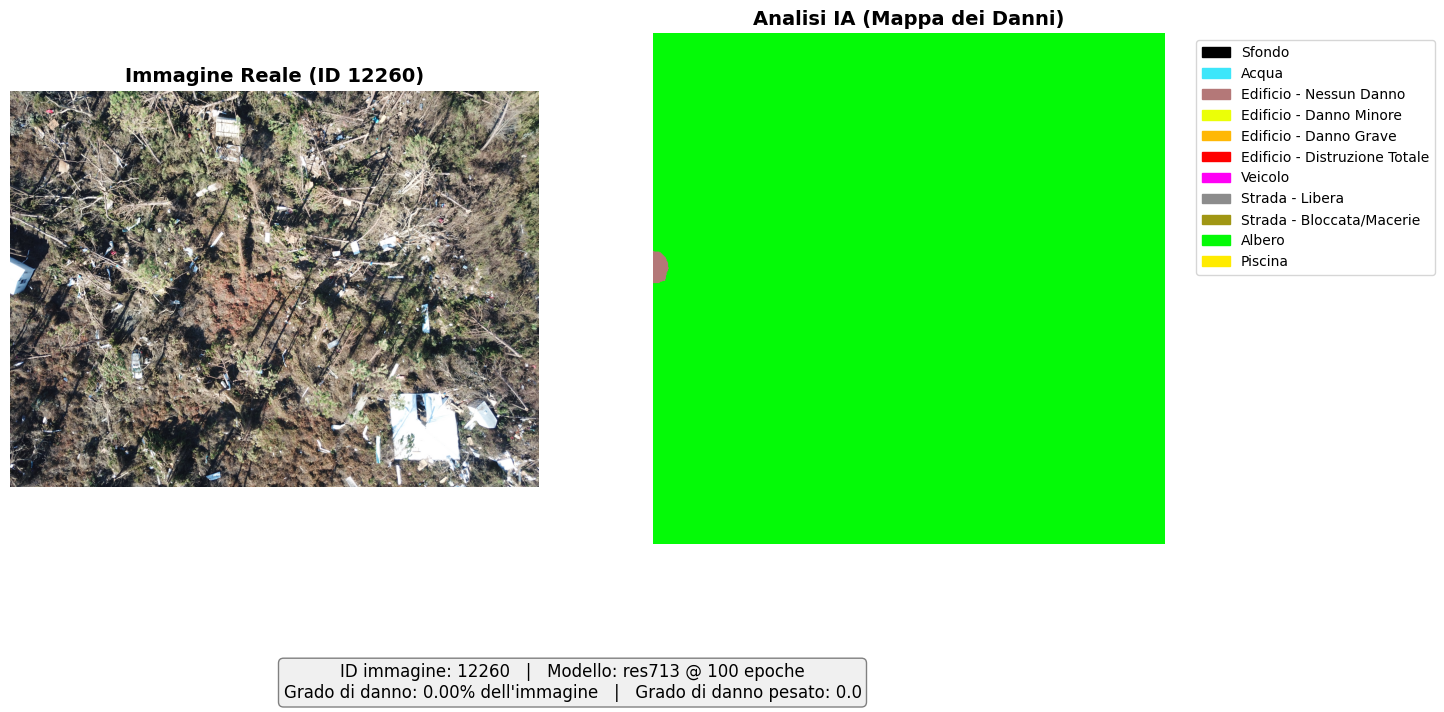

In [ ]:
import os, re, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

SEED = None          # None = casuale (stampa il seed) · un numero = riproducibile

COLORI = {
    (0,0,0):'Sfondo', (61,230,250):'Acqua',
    (180,120,120):'Edificio - Nessun Danno', (235,255,7):'Edificio - Danno Minore',
    (255,184,6):'Edificio - Danno Grave', (255,0,0):'Edificio - Distruzione Totale',
    (255,0,245):'Veicolo', (140,140,140):'Strada - Libera',
    (160,150,20):'Strada - Bloccata/Macerie', (4,250,7):'Albero', (255,235,0):'Piscina'
}
PESI = {'Edificio - Nessun Danno':0, 'Edificio - Danno Minore':1,
        'Edificio - Danno Grave':3, 'Edificio - Distruzione Totale':5,
        'Strada - Bloccata/Macerie':2.5}

# --- Cartella maschere del modello più allenato ---
cart = glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*')
if not cart:
    raise SystemExit(f"Nessuna cartella predictions_{REGIME}_ep*. Esegui prima la cella 6.")
def n_ep(p):
    m = re.search(r'_ep(\d+)$', p); return int(m.group(1)) if m else -1
PRED_DIR = max(cart, key=n_ep); EP = n_ep(PRED_DIR)
print(f"Maschere: {REGIME} @ {EP} epoche\n")

def trova_orig(base):
    for c in [ORIG_DIR, '/content/dataset/test/test-org-img']:
        for e in ['.jpg', '.JPG', '.png']:
            p = os.path.join(c, base + e)
            if os.path.exists(p): return p
    return None

valide = [f for f in os.listdir(PRED_DIR)
          if f.endswith('.png') and trova_orig(f[:-4])]
if not valide:
    raise SystemExit("Nessuna coppia maschera+originale disponibile.")

seed = SEED if SEED is not None else random.randint(0, 999999)
random.seed(seed)
scelti = random.sample(valide, min(2, len(valide)))
print(f"SEED usato: {seed}   (per rivedere questi esempi: SEED = {seed})")
print(f"Immagini: {[s[:-4] for s in scelti]}\n")

for nome in scelti:
    base = nome[:-4]
    img_org  = Image.open(trova_orig(base))
    img_pred = Image.open(os.path.join(PRED_DIR, nome))

    arr = np.array(img_pred.convert('RGB'))
    tot = arr.shape[0] * arr.shape[1]
    cols, cnts = np.unique(arr.reshape(-1, 3), axis=0, return_counts=True)
    perc, pesato = {}, 0.0
    for c, n in zip(cols, cnts):
        t = tuple(int(x) for x in c)
        if t in COLORI:
            p = n / tot * 100
            perc[COLORI[t]] = p
            pesato += p * PESI.get(COLORI[t], 0)
    danneggiati = ['Edificio - Danno Minore', 'Edificio - Danno Grave',
                   'Edificio - Distruzione Totale']
    perc_danno = sum(perc.get(c, 0) for c in danneggiati)

    testo = (f"ID immagine: {base}   |   Modello: {REGIME} @ {EP} epoche\n"
             f"Grado di danno: {perc_danno:.2f}% dell'immagine   |   "
             f"Grado di danno pesato: {pesato:.1f}")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))
    a1.imshow(img_org);  a1.set_title(f"Immagine Reale (ID {base})", fontsize=14, fontweight='bold')
    a2.imshow(img_pred); a2.set_title("Analisi IA (Mappa dei Danni)", fontsize=14, fontweight='bold')
    a1.axis('off'); a2.axis('off')
    patches = [mpatches.Patch(color='#%02x%02x%02x' % rgb, label=l) for rgb, l in COLORI.items()]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, fontsize=10)
    fig.text(0.5, -0.02, testo, ha='center', va='top', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))
    plt.subplots_adjust(bottom=0.15)
    plt.show()

## 8 · Confronto originale · ground truth · predizione

Con `INTERATTIVO = False` non blocca *Esegui tutto*: usa l'epoca più alta
(o quella indicata in `EPOCA_SCELTA`). Mettilo a `True` se preferisci
scegliere l'epoca da tastiera lanciando la cella singolarmente.

Richiede le ground truth colorate su Drive in `colormasks/` (nomi con `_lab`).

Epoche disponibili per res713: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Modello: res713 @ 100 epoche

Immagine estratta a caso: 15334


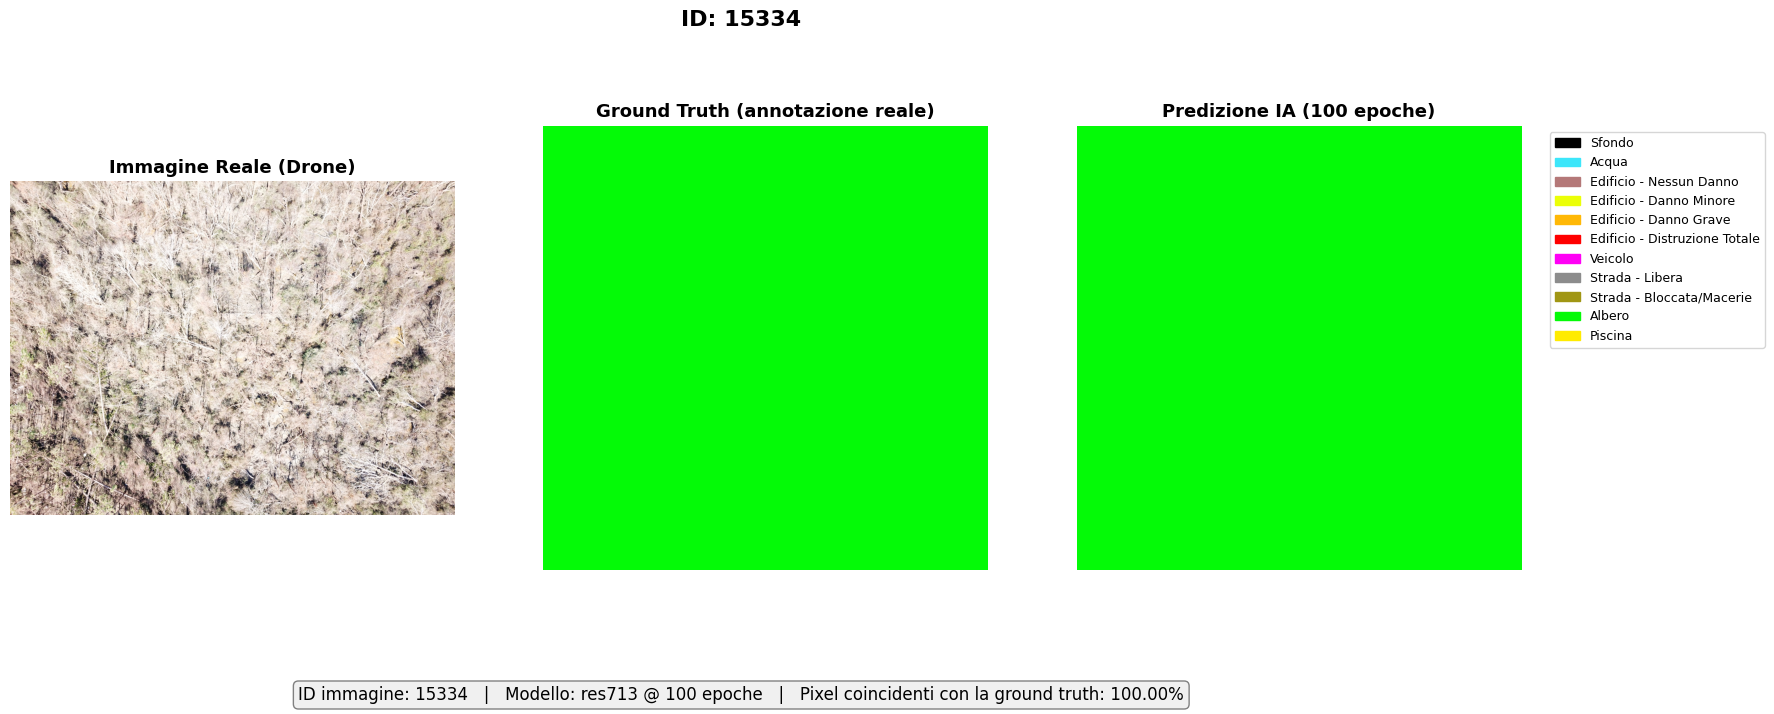

In [ ]:
import os, re, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

INTERATTIVO  = False      # True = chiede l'epoca da tastiera (blocca 'Esegui tutto')
EPOCA_SCELTA = None       # usato se INTERATTIVO=False; None = epoca più alta
MODALITA     = 'random'   # 'id' oppure 'random'
IMMAGINE_ID  = '10794'

cart = sorted(glob.glob(f'{DRIVE_BASE}/predictions_{REGIME}_ep*'),
              key=lambda p: int(re.search(r'_ep(\d+)$', p).group(1)))
epoche = [int(re.search(r'_ep(\d+)$', c).group(1)) for c in cart]
if not epoche:
    raise SystemExit(f"Nessuna cartella predictions_{REGIME}_ep*.")

print(f"Epoche disponibili per {REGIME}: {epoche}")
if INTERATTIVO:
    scelta = input(f"Quale epoca? (invio = {max(epoche)}): ").strip()
    EP = int(scelta) if scelta else max(epoche)
else:
    EP = EPOCA_SCELTA if EPOCA_SCELTA is not None else max(epoche)
if EP not in epoche:
    raise SystemExit(f"Epoca {EP} non disponibile. Scegli fra {epoche}")
PRED_DIR = f'{DRIVE_BASE}/predictions_{REGIME}_ep{EP}'
print(f"Modello: {REGIME} @ {EP} epoche\n")

disponibili = sorted(f[:-4] for f in os.listdir(PRED_DIR) if f.endswith('.png'))
if MODALITA == 'random':
    IMMAGINE_ID = random.choice(disponibili)
    print(f"Immagine estratta a caso: {IMMAGINE_ID}")
elif IMMAGINE_ID not in disponibili:
    raise SystemExit(f"Immagine '{IMMAGINE_ID}' non trovata. Esempi: {disponibili[:8]}")

def apri(cartella, nome, estensioni):
    for e in estensioni:
        p = os.path.join(cartella, nome + e)
        if os.path.exists(p): return Image.open(p)
    return None

img_org  = apri(ORIG_DIR, IMMAGINE_ID, ['.jpg','.JPG','.png'])
img_gt   = apri(GT_DIR,   IMMAGINE_ID + '_lab', ['.png','.jpg'])
img_pred = apri(PRED_DIR, IMMAGINE_ID, ['.png'])
if img_org is None:  raise SystemExit(f"Originale non trovato in {ORIG_DIR}")
if img_pred is None: raise SystemExit(f"Predizione non trovata in {PRED_DIR}")
if img_gt is None:   print(f"Ground truth '{IMMAGINE_ID}_lab.png' non trovata in {GT_DIR}")

COLORI = {
    (0,0,0):'Sfondo', (61,230,250):'Acqua',
    (180,120,120):'Edificio - Nessun Danno', (235,255,7):'Edificio - Danno Minore',
    (255,184,6):'Edificio - Danno Grave', (255,0,0):'Edificio - Distruzione Totale',
    (255,0,245):'Veicolo', (140,140,140):'Strada - Libera',
    (160,150,20):'Strada - Bloccata/Macerie', (4,250,7):'Albero', (255,235,0):'Piscina'
}

info = f"ID immagine: {IMMAGINE_ID}   |   Modello: {REGIME} @ {EP} epoche"
if img_gt is not None:
    a = np.array(img_pred.convert('RGB'))
    b = np.array(img_gt.convert('RGB').resize(img_pred.size, Image.NEAREST))
    info += f"   |   Pixel coincidenti con la ground truth: {float(np.all(a==b,axis=-1).mean())*100:.2f}%"

pannelli = [(img_org, "Immagine Reale (Drone)")]
if img_gt is not None:
    pannelli.append((img_gt, "Ground Truth (annotazione reale)"))
pannelli.append((img_pred, f"Predizione IA ({EP} epoche)"))

fig, axes = plt.subplots(1, len(pannelli), figsize=(6.5*len(pannelli), 6.5))
if len(pannelli) == 1: axes = [axes]
for ax, (im, tit) in zip(axes, pannelli):
    ax.imshow(im); ax.set_title(tit, fontsize=13, fontweight='bold'); ax.axis('off')
fig.suptitle(f"ID: {IMMAGINE_ID}", fontsize=16, fontweight='bold', y=1.02)
patches = [mpatches.Patch(color='#%02x%02x%02x' % rgb, label=l) for rgb, l in COLORI.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, fontsize=9)
fig.text(0.5, -0.02, info, ha='center', va='top', fontsize=12,
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))
plt.subplots_adjust(bottom=0.12)
plt.show()